# Notebook 03: Laplacian Mixture Model (LMM)

In this notebook, we test our first robust alternative to the Gaussian baseline: the **Laplacian Distribution**. 

While a Gaussian (Normal) distribution forms a soft bell curve, a Laplacian distribution has a sharper peak and "heavier tails."  This means it is much more forgiving of extreme outliers, like digits that are drawn very strangely, without letting those weirdly drawn digits distort the core shape of the cluster.

**Steps:**
1. Load the preprocessed PCA dataset.
2. Implement a Expectation-Maximization (EM) algorithm for the Laplacian distribution.
3. Train the model using the optimal $K=25$ we discovered in the GMM notebook.
4. Evaluate using Purity/Accuracy, ARI, NMI, and plot the Confusion Matrix.
5. Generate new handwritten digits using `np.random.laplace`.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from scipy.stats import mode
from tqdm import trange
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score, confusion_matrix

# Load the full 70k processed data
X_pca = np.load('data/X_pca.npy')
y = np.load('data/y_labels.npy')

with open('data/pca_model.pkl', 'rb') as f:
    pca = pickle.load(f)

print(f"Loaded X_pca shape: {X_pca.shape}")
print(f"Loaded labels shape: {y.shape}")

Loaded X_pca shape: (70000, 50)
Loaded labels shape: (70000,)


### Step 1: The Laplacian Expectation-Maximization (EM) Algorithm

Since standard libraries don't have a Laplacian Mixture Model, we implement it.

In [10]:
class LaplacianMixtureModel:
    def __init__(self, n_components=25, max_iter=50, tol=1e-4, verbose=True):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose

    def _laplace_log_pdf(self, x, mu, b):
        return -np.log(2 * b + 1e-10) - np.abs(x - mu) / (b + 1e-10)

    def _e_step(self, X):
        N, D = X.shape
        log_resp = np.zeros((N, self.K))
        for k in range(self.K):
            log_pdf = np.sum(self._laplace_log_pdf(X, self.mu[k], self.b[k]), axis=1)
            log_resp[:, k] = np.log(self.pi[k] + 1e-10) + log_pdf

        max_log_resp = np.max(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - max_log_resp)
        resp /= resp.sum(axis=1, keepdims=True)
        return resp

    def _m_step(self, X, resp):
        N, D = X.shape
        Nk = resp.sum(axis=0)
        self.pi = Nk / N

        for k in range(self.K):
            mu_k = np.zeros(D)
            # The Median Trick for Laplacian centers
            for d in range(D):
                sorted_idx = np.argsort(X[:, d])
                sorted_X = X[sorted_idx, d]
                sorted_weights = resp[sorted_idx, k]
                cum_weights = np.cumsum(sorted_weights)
                median_idx = np.searchsorted(cum_weights, Nk[k] / 2)
                mu_k[d] = sorted_X[median_idx]
            self.mu[k] = mu_k
            self.b[k] = np.sum(resp[:, k][:, None] * np.abs(X - self.mu[k]), axis=0) / Nk[k]
            self.b[k] = np.clip(self.b[k], 1e-3, None)

    def fit(self, X):
        N, D = X.shape
        # Smart initialization using KMeans
        km = KMeans(n_clusters=self.K, init='k-means++', n_init=10).fit(X)
        self.mu = km.cluster_centers_
        self.b = np.ones((self.K, D))
        self.pi = np.ones(self.K) / self.K
        self.loss_history = []

        progress = trange(self.max_iter, desc="Training LMM", leave=True)
        for i in progress:
            resp = self._e_step(X)
            self._m_step(X, resp)

            if self.verbose:
                log_resp = np.zeros((X.shape[0], self.K))
                for k in range(self.K):
                    log_pdf = np.sum(self._laplace_log_pdf(X, self.mu[k], self.b[k]), axis=1)
                    log_resp[:, k] = np.log(self.pi[k] + 1e-10) + log_pdf

                max_log = np.max(log_resp, axis=1, keepdims=True)
                
                log_likelihood = np.sum(max_log + np.log(np.sum(np.exp(log_resp - max_log), axis=1, keepdims=True) + 1e-10))
                
                progress.set_description(f"Iter {i+1} | LogL: {log_likelihood:.2f}")
                
                # Check for convergence
                if len(self.loss_history) > 0 and np.abs(log_likelihood - self.loss_history[-1]) < self.tol:
                    print(f"\nConverged at iteration {i+1}")
                    break
                self.loss_history.append(log_likelihood)

    def predict(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            log_pdf = np.sum(self._laplace_log_pdf(X, self.mu[k], self.b[k]), axis=1)
            log_resp[:, k] = np.log(self.pi[k] + 1e-10) + log_pdf
        return np.argmax(log_resp, axis=1)

    def sample(self, n_samples=10):
        # Inverse Transform Sampling for Laplacian
        samples = []
        component_ids = np.random.choice(self.K, size=n_samples, p=self.pi)
        for k in component_ids:
            mu_k = self.mu[k]
            b_k = self.b[k]
            u = np.random.uniform(low=-0.5, high=0.5, size=mu_k.shape)
            x = mu_k - b_k * np.sign(u) * np.log(1 - 2 * np.abs(u))
            samples.append(x)
        return np.array(samples)

### Step 2: Training 
We will use $K=25$ to match our baseline Gaussian evaluation. 

Iter 50 | LogL: -3617629.95: 100%|██████████| 50/50 [06:07<00:00,  7.35s/it]


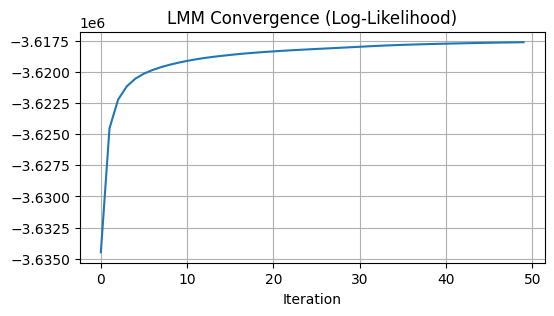

In [11]:
OPTIMAL_K = 25

lmm = LaplacianMixtureModel(n_components=OPTIMAL_K, max_iter=50, verbose=True)
lmm.fit(X_pca)

clusters = lmm.predict(X_pca)

# Plot the Log-Likelihood curve to prove convergence
plt.figure(figsize=(6, 3))
plt.plot(lmm.loss_history)
plt.title("LMM Convergence (Log-Likelihood)")
plt.xlabel("Iteration")
plt.grid(True)
plt.show()

### Step 3: Evaluation


--- LMM Evaluation Metrics (K=25) ---
Mapped Accuracy (Purity): 70.71%
ARI: 0.2886
NMI: 0.5385



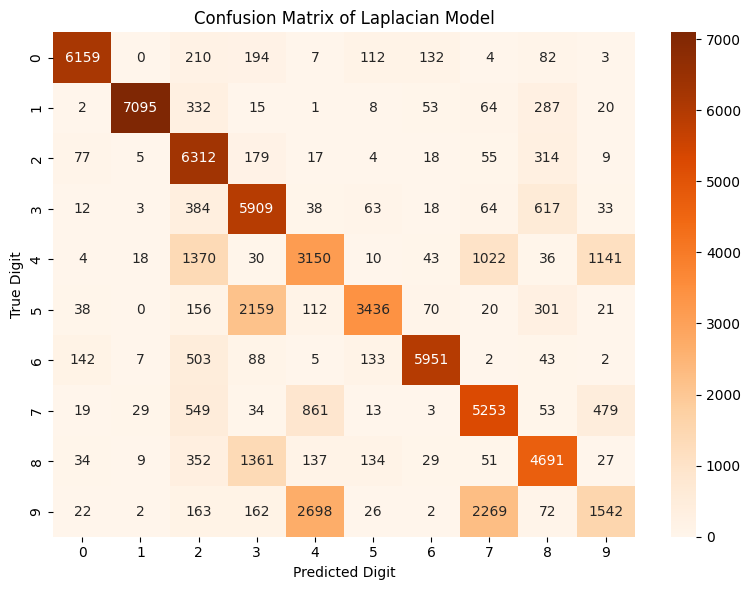

In [14]:
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

def map_clusters_to_digits(y_true, y_pred, n_clusters):
    labels = np.zeros_like(y_pred)
    for cluster in range(n_clusters):
        mask = (y_pred == cluster)
        if np.any(mask):
            labels[mask] = mode(y_true[mask], keepdims=False).mode
    return labels

y_pred_mapped = map_clusters_to_digits(y, clusters, n_clusters=OPTIMAL_K)
acc = accuracy_score(y, y_pred_mapped)

print(f"--- LMM Evaluation Metrics (K={OPTIMAL_K}) ---")
print(f"Mapped Accuracy (Purity): {acc * 100:.2f}%")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}\n")

cm = confusion_matrix(y, y_pred_mapped, labels=range(10))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.title('Confusion Matrix of Laplacian Model')
plt.tight_layout()
plt.show()

laplacian_metrics = {'Accuracy': acc, 'ARI': ari, 'NMI': nmi}
with open('data/laplacian_metrics.pkl', 'wb') as f:
    pickle.dump(laplacian_metrics, f)

### Step 4: Generative Sampling
Finally, we draw samples from our newly trained Laplacian distributions. 

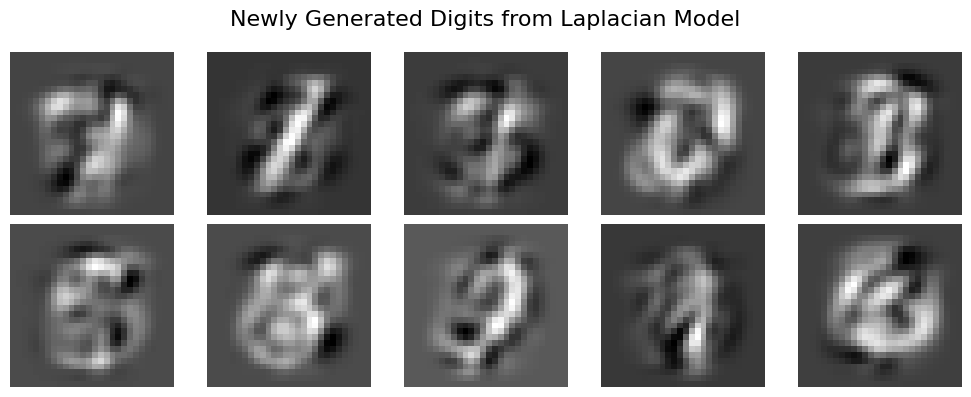

In [18]:
# 1. Sample 10 new data points from the learned Laplacian distributions
new_pca_samples = lmm.sample(n_samples=10)

# 2. Uncompress from 50 dims back to 784 dims
generated_digits_flat = pca.inverse_transform(new_pca_samples)

# 3. Plot the generated digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Newly Generated Digits from Laplacian Model", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    img = generated_digits_flat[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Save the fully uncompressed 784-dimensional generated images
np.save('data/lmm_samples.npy', generated_digits_flat)